# 10 — Model Training: Random Forest, Bagging & Baseline

**Author:** Zeineb Turki  
**Date:** April 2026  
**Phase:** 7 — Model Training  

## Objective

Train and evaluate three classifiers on the triple-barrier-labeled events:

1. **Random Forest** — bootstrap + random feature subsets at each split
2. **Bagging** (with Decision Trees) — bootstrap only, all features at each split
3. **Baseline** — stratified dummy classifier (sanity check)

We use a **temporal 60/20/20 split** (train/validation/test) to prevent lookahead bias,
then compare models on accuracy, F1, confusion matrices, and feature importance.

**Key questions:**
- Can tree ensembles learn to predict label outcomes from technical indicators and pattern geometry?
- Does the random feature subset (RF) provide an advantage over bootstrap-only (Bagging)?
- Which features matter most for prediction?

In [1]:
import sys, os
from pathlib import Path

# Clear cached src modules for clean reload
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('src'):
        del sys.modules[mod_name]

# Environment setup (Colab or local)
if 'google.colab' in str(getattr(sys, 'modules', {})) or os.path.exists('/content'):
    REPO_DIR  = '/content/regime-aware-ml-trading'
    PROJ_ROOT = os.path.join(REPO_DIR, 'regime-aware-ml-trading')
    if not os.path.isdir(PROJ_ROOT):
        os.system('git clone https://github.com/zaetae/regime-aware-ml-trading.git ' + REPO_DIR)
    else:
        os.system(f'cd {REPO_DIR} && git pull -q')
    os.system(f'{sys.executable} -m pip install -q yfinance hmmlearn scikit-learn seaborn statsmodels')
    _spy_path = os.path.join(PROJ_ROOT, 'data', 'raw', 'spy.csv')
    if not os.path.isfile(_spy_path):
        os.makedirs(os.path.dirname(_spy_path), exist_ok=True)
        import yfinance as yf
        import pandas as pd
        _spy = yf.download('SPY', start='2010-01-01', end='2026-01-01', auto_adjust=False)
        if isinstance(_spy.columns, pd.MultiIndex):
            _spy.columns = _spy.columns.droplevel(1)
        _spy = _spy[['Open', 'High', 'Low', 'Close', 'Volume']]
        if _spy.index.tz is not None:
            _spy.index = _spy.index.tz_localize(None)
        _spy.index.name = 'Date'
        _spy.to_csv(_spy_path)
        print(f"Downloaded SPY data to {_spy_path}")
else:
    def _find_project_root():
        current = Path.cwd()
        for _ in range(10):
            if (current / "src").is_dir():
                return current
            current = current.parent
        return Path.cwd().parent if (Path.cwd().parent / "src").is_dir() else Path.cwd()
    PROJ_ROOT = str(_find_project_root())

sys.path.insert(0, PROJ_ROOT)
os.chdir(PROJ_ROOT)

%matplotlib inline

from src.data.load_data import load_spy
from src.features.build_features import build_feature_matrix
from src.models.train import (
    run_training_pipeline, temporal_split,
    train_random_forest, train_bagging, train_baseline,
    evaluate_model, tree_complexity_stats, feature_importance_table
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = load_spy()
print(f'Loaded {len(df)} bars: {df.index[0].date()} to {df.index[-1].date()}')
print('Imports OK')

Loaded 4023 bars: 2010-01-04 to 2025-12-30
Imports OK


---

## 1. Build Feature Matrix

The feature matrix is built from:
- **Bar-level technical indicators** (ATR, RSI, MACD, Bollinger Bands, moving averages, momentum, volume features)
- **Pattern geometry features** (slopes, containment, touch counts, channel width)
- **Event type dummies** (one-hot encoding of the detection type)
- **Event metadata** (entry price, ATR at event)

Each row is one labeled event. All features use only information available at or before the event bar (no lookahead).

In [2]:
# Build the feature matrix (this runs pattern detection + labeling internally)
features, labels, labeled_df = build_feature_matrix(df)

print(f'Feature matrix shape: {features.shape}')
print(f'  Rows (events):    {features.shape[0]}')
print(f'  Columns (features): {features.shape[1]}')
print(f'\nLabel distribution:')
print(labels.value_counts().to_string())
print(f'\nFeature columns:')
for i, col in enumerate(features.columns, 1):
    print(f'  {i:>2}. {col}')

Feature matrix shape: (221, 55)
  Rows (events):    221
  Columns (features): 55

Label distribution:
label
long        88
no_trade    69
short       64

Feature columns:
   1. atr_14
   2. atr_ratio
   3. rvol_20
   4. ret_1
   5. ret_5
   6. ret_10
   7. ret_20
   8. sma_10
   9. sma_10_dist
  10. sma_20
  11. sma_20_dist
  12. sma_50
  13. sma_50_dist
  14. sma_100
  15. sma_100_dist
  16. sma_200
  17. sma_200_dist
  18. ma_spread_10_50
  19. ma_spread_20_200
  20. ma_spread_50_200
  21. rsi_14
  22. macd
  23. macd_signal
  24. macd_hist
  25. bb_width
  26. bb_pctb
  27. mom_5
  28. mom_10
  29. mom_20
  30. volume_ratio
  31. volume_std
  32. obv_norm
  33. upper_slope
  34. lower_slope
  35. containment
  36. upper_touches
  37. lower_touches
  38. total_touches
  39. upper_mean_error
  40. lower_mean_error
  41. pattern_window
  42. channel_width_atr
  43. r_upper
  44. r_lower
  45. etype_ascending_triangle
  46. etype_channel_down
  47. etype_channel_up
  48. etype_descendin

In [3]:
# Feature matrix statistics
print('Feature matrix summary statistics:')
print('=' * 70)
desc = features.describe().T
desc['missing'] = features.isna().sum()
desc['missing_%'] = (features.isna().sum() / len(features) * 100).round(1)
print(desc[['count', 'mean', 'std', 'min', 'max', 'missing', 'missing_%']].to_string())

Feature matrix summary statistics:
                   count        mean         std        min         max  missing  missing_%
atr_14             221.0    3.597620    3.114276   0.710356   24.156057        0        0.0
atr_ratio          221.0    0.012834    0.007937   0.004043    0.079298        0        0.0
rvol_20            221.0    0.145030    0.091293   0.038297    0.909851        0        0.0
ret_1              221.0    0.002205    0.012905  -0.078094    0.090603        0        0.0
ret_5              221.0    0.002840    0.024241  -0.112782    0.056657        0        0.0
ret_10             221.0    0.002484    0.033672  -0.152001    0.098031        0        0.0
ret_20             221.0    0.004333    0.041249  -0.217720    0.073686        0        0.0
sma_10             221.0  277.040443  156.878169  79.999747  681.294843        0        0.0
sma_10_dist        221.0    0.002216    0.018374  -0.090224    0.033617        0        0.0
sma_20             221.0  276.978665  156.600

---

## 2. Temporal Split (60/20/20)

We split the labeled events **chronologically** into three sets:

| Set | Fraction | Purpose |
|-----|----------|---------|
| **Train** | 60% | Fit model parameters |
| **Validation** | 20% | Tune hyperparameters, select model |
| **Test** | 20% | Final unbiased evaluation |

**Why temporal (not random)?**  
Financial data has temporal autocorrelation. A random split would leak future information
into the training set, inflating performance metrics. The temporal split ensures the model
is always trained on past data and evaluated on future data — matching real deployment.

In [4]:
# Perform the temporal split
features_clean = features.fillna(0)
split = temporal_split(features_clean, labels, labeled_df,
                       train_frac=0.6, val_frac=0.2)

print('Temporal Split Summary:')
print('=' * 55)
for name in ['train', 'val', 'test']:
    X = split[f'X_{name}']
    y = split[f'y_{name}']
    dates = split[f'dates_{name}']
    print(f'  {name.upper():>5s}:  {len(X):>4} samples  |  '
          f'{dates.min().date()} to {dates.max().date()}')

Temporal Split Summary:
  TRAIN:   132 samples  |  2010-04-14 to 2019-12-12
    VAL:    44 samples  |  2019-12-19 to 2023-01-03
   TEST:    45 samples  |  2023-01-26 to 2025-12-10


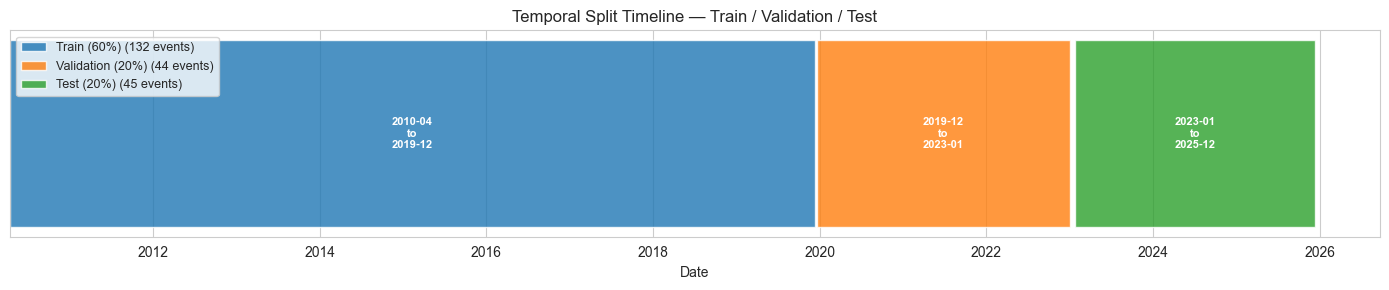

In [5]:
# Timeline visualization of the split
fig, ax = plt.subplots(figsize=(14, 3))

split_colors = {'train': '#1f77b4', 'val': '#ff7f0e', 'test': '#2ca02c'}
split_labels = {'train': 'Train (60%)', 'val': 'Validation (20%)', 'test': 'Test (20%)'}

for i, name in enumerate(['train', 'val', 'test']):
    dates = split[f'dates_{name}']
    start = dates.min()
    end = dates.max()
    ax.barh(0, (end - start).days, left=start, height=0.5,
            color=split_colors[name], alpha=0.8,
            label=f'{split_labels[name]} ({len(split[f"X_{name}"])} events)')
    # Annotate with date range
    mid = start + (end - start) / 2
    ax.text(mid, 0, f'{start.strftime("%Y-%m")}\nto\n{end.strftime("%Y-%m")}',
            ha='center', va='center', fontsize=8, fontweight='bold', color='white')

ax.set_yticks([])
ax.set_xlabel('Date')
ax.set_title('Temporal Split Timeline — Train / Validation / Test', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Class Distribution in Each Split

We check that all three classes are represented in each split. Severe imbalance in
any split would require resampling or adjusted thresholds.

Class Distribution by Split:
Split  Total  long (n)  long (%)  short (n)  short (%)  no_trade (n)  no_trade (%)
TRAIN    132        53      40.2         38       28.8            41          31.1
  VAL     44        18      40.9         14       31.8            12          27.3
 TEST     45        17      37.8         12       26.7            16          35.6


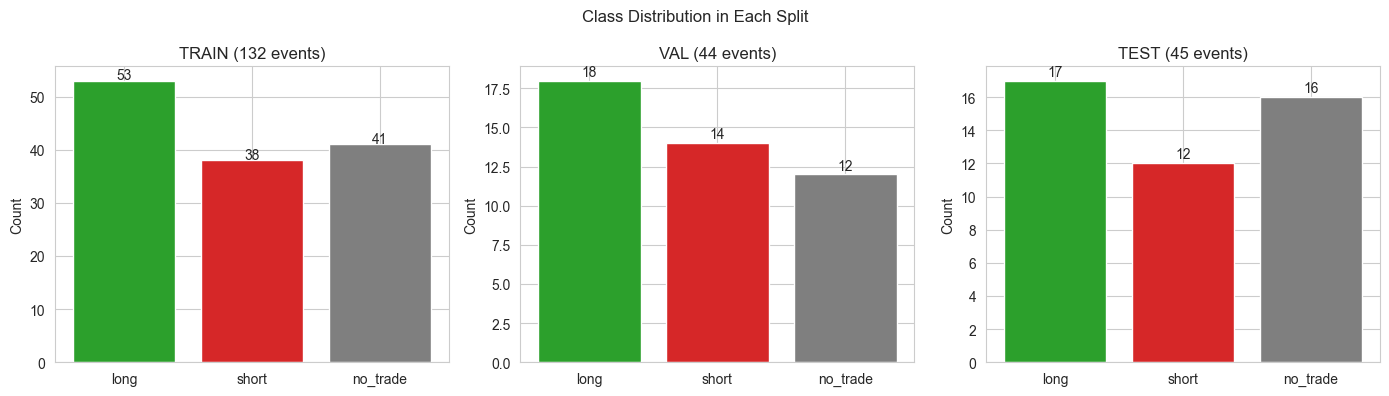

In [6]:
# Class distribution table
label_order = ['long', 'short', 'no_trade']
colors_map = {'long': '#2ca02c', 'short': '#d62728', 'no_trade': '#7f7f7f'}

dist_rows = []
for name in ['train', 'val', 'test']:
    y = split[f'y_{name}']
    row = {'Split': name.upper(), 'Total': len(y)}
    for lbl in label_order:
        n = (y == lbl).sum()
        row[f'{lbl} (n)'] = n
        row[f'{lbl} (%)'] = round(n / len(y) * 100, 1)
    dist_rows.append(row)

dist_table = pd.DataFrame(dist_rows)
print('Class Distribution by Split:')
print(dist_table.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, name in enumerate(['train', 'val', 'test']):
    y = split[f'y_{name}']
    counts = y.value_counts().reindex(label_order, fill_value=0)
    axes[i].bar(counts.index, counts.values,
                color=[colors_map[l] for l in counts.index])
    axes[i].set_title(f'{name.upper()} ({len(y)} events)')
    axes[i].set_ylabel('Count')
    for j, (lbl, cnt) in enumerate(counts.items()):
        axes[i].text(j, cnt + 0.3, str(cnt), ha='center', fontsize=10)

plt.suptitle('Class Distribution in Each Split', fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. How Random Forest and Bagging Work

Both Random Forest and Bagging are **ensemble methods** that combine many decision trees
to reduce variance. Their key difference lies in how they create diversity among trees.

### Random Forest

Random Forest introduces diversity through **two sources of randomness**:

1. **Bootstrap sampling:** Each tree is trained on a bootstrap sample — a random draw of *n*
   samples with replacement from the training set. On average, each bootstrap sample contains
   about 63.2% of unique training observations (the rest are duplicates). The ~36.8% left out
   are called out-of-bag (OOB) samples.

2. **Random feature subsets:** At each split in each tree, only a random subset of features
   (typically `sqrt(n_features)`) is considered. This prevents all trees from splitting on
   the same dominant feature, forcing them to learn different patterns.

The final prediction is the **majority vote** across all trees.

### Bagging (Bootstrap Aggregating)

Bagging uses **only bootstrap sampling** for diversity:

1. **Bootstrap sampling:** Same as RF — each tree gets a different random sample.
2. **All features available:** Unlike RF, every split considers all features. There is no
   random feature restriction.

### Why Bagging Produces Less Diversity Than RF

When all features are available at each split, trees tend to make similar choices —
especially if one feature is clearly dominant. This creates **correlated trees**, and
averaging correlated predictions reduces less variance than averaging uncorrelated ones.

The variance of an average of *B* identically distributed random variables with
pairwise correlation `rho` and variance `sigma^2` is:

> `Var = rho * sigma^2 + (1 - rho) * sigma^2 / B`

RF reduces `rho` by forcing different feature subsets, so it benefits more from adding trees.
Bagging has higher `rho`, so the first term dominates and more trees help less.

### How Bootstrap Sampling Works

Given *n* training samples, a bootstrap sample draws *n* samples **independently with
replacement**. Each draw is independent — the probability of selecting any particular
sample is always 1/n, regardless of previous draws. This means:
- Some samples appear multiple times
- Some samples are never selected (~36.8%)
- Each bootstrap sample is a slightly different view of the data

### Baseline (Dummy Classifier)

The stratified baseline predicts labels according to the training set's class frequencies.
It provides a floor: any useful model must beat this.

---

## 5. Train All Three Models

We train:
- **Random Forest**: 200 trees, max_depth=8, `class_weight="balanced"`
- **Bagging**: 200 trees (DecisionTreeClassifier base), max_depth=8
- **Baseline**: Stratified dummy classifier

In [7]:
# Run the full training pipeline
results = run_training_pipeline(
    features, labels, labeled_df,
    train_frac=0.6, val_frac=0.2,
    n_estimators=200, max_depth=8,
    random_state=42
)

# Extract for convenience
rf_model = results['models']['rf']
bag_model = results['models']['bagging']
base_model = results['models']['baseline']

split = results['split']

print('Training complete.')
print(f'  Random Forest:  {type(rf_model).__name__}')
print(f'  Bagging:        {type(bag_model).__name__}')
print(f'  Baseline:       {type(base_model).__name__}')

Training complete.
  Random Forest:  RandomForestClassifier
  Bagging:        BaggingClassifier
  Baseline:       DummyClassifier


## 6. Hyperparameters Table

Summary of the hyperparameters used for each model.

In [8]:
# Hyperparameters table
hp_data = {
    'Parameter': [
        'n_estimators',
        'max_depth',
        'class_weight',
        'max_features (per split)',
        'bootstrap',
        'base estimator',
        'random_state',
        'n_jobs',
    ],
    'Random Forest': [
        rf_model.n_estimators,
        rf_model.max_depth,
        str(rf_model.class_weight),
        f'sqrt({features.shape[1]}) = {int(np.sqrt(features.shape[1]))}',
        'True (default)',
        'DecisionTreeClassifier',
        rf_model.random_state,
        rf_model.n_jobs,
    ],
    'Bagging': [
        bag_model.n_estimators,
        bag_model.estimator.max_depth,
        'None (not supported)',
        f'All ({features.shape[1]})',
        'True (default)',
        'DecisionTreeClassifier',
        bag_model.random_state,
        bag_model.n_jobs,
    ],
    'Baseline': [
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        'DummyClassifier (stratified)',
        base_model.random_state,
        'N/A',
    ],
}

hp_table = pd.DataFrame(hp_data)
print('Model Hyperparameters:')
print(hp_table.to_string(index=False))

Model Hyperparameters:
               Parameter          Random Forest                Bagging                     Baseline
            n_estimators                    200                    200                          N/A
               max_depth                      8                      8                          N/A
            class_weight               balanced   None (not supported)                          N/A
max_features (per split)           sqrt(55) = 7               All (55)                          N/A
               bootstrap         True (default)         True (default)                          N/A
          base estimator DecisionTreeClassifier DecisionTreeClassifier DummyClassifier (stratified)
            random_state                     42                     42                           42
                  n_jobs                     -1                     -1                          N/A


## 7. Tree Complexity Statistics

How complex are the individual trees within each ensemble? Deeper trees with more
leaves have higher capacity but also higher overfitting risk.

In [9]:
# Tree complexity stats
rf_stats = results['tree_stats']['rf']
bag_stats = results['tree_stats']['bagging']

tree_data = {
    'Metric': [
        'Number of trees',
        'Actual depth (min)',
        'Actual depth (mean)',
        'Actual depth (max)',
        'Leaves per tree (min)',
        'Leaves per tree (mean)',
        'Leaves per tree (max)',
        'Nodes per tree (min)',
        'Nodes per tree (mean)',
        'Nodes per tree (max)',
    ],
    'Random Forest': [
        rf_stats['n_trees'],
        rf_stats['min_depth'],
        rf_stats['mean_depth'],
        rf_stats['max_depth'],
        rf_stats['min_leaves'],
        rf_stats['mean_leaves'],
        rf_stats['max_leaves'],
        rf_stats['min_nodes'],
        rf_stats['mean_nodes'],
        rf_stats['max_nodes'],
    ],
    'Bagging': [
        bag_stats['n_trees'],
        bag_stats['min_depth'],
        bag_stats['mean_depth'],
        bag_stats['max_depth'],
        bag_stats['min_leaves'],
        bag_stats['mean_leaves'],
        bag_stats['max_leaves'],
        bag_stats['min_nodes'],
        bag_stats['mean_nodes'],
        bag_stats['max_nodes'],
    ],
}

tree_table = pd.DataFrame(tree_data)
print('Tree Complexity Statistics:')
print(tree_table.to_string(index=False))

Tree Complexity Statistics:
                Metric  Random Forest  Bagging
       Number of trees          200.0    200.0
    Actual depth (min)            7.0      6.0
   Actual depth (mean)            8.0      7.8
    Actual depth (max)            8.0      8.0
 Leaves per tree (min)           16.0     16.0
Leaves per tree (mean)           30.5     24.1
 Leaves per tree (max)           39.0     31.0
  Nodes per tree (min)           31.0     31.0
 Nodes per tree (mean)           59.9     47.2
  Nodes per tree (max)           77.0     61.0


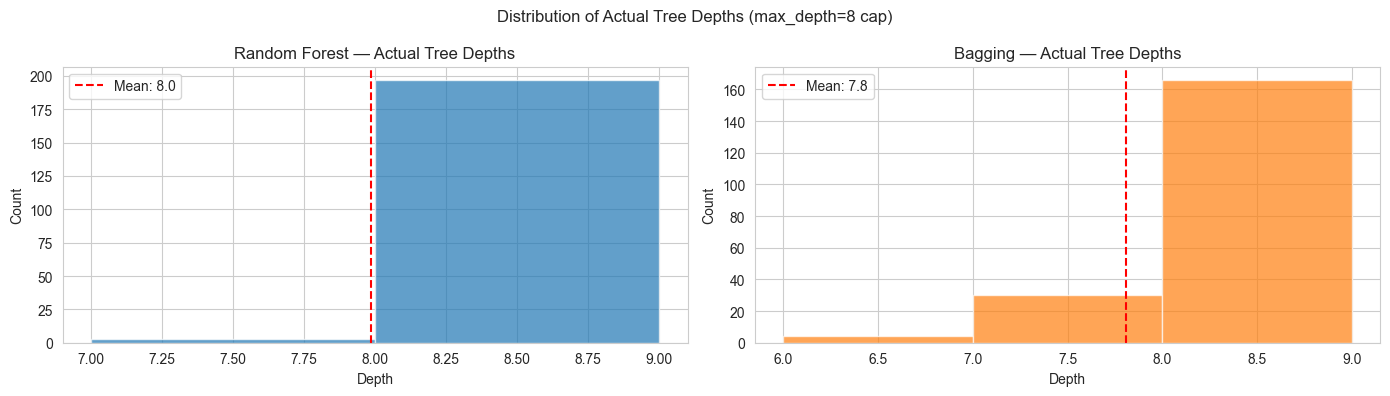

In [10]:
# Distribution of tree depths
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rf_depths = [t.tree_.max_depth for t in rf_model.estimators_]
bag_depths = [t.tree_.max_depth for t in bag_model.estimators_]

axes[0].hist(rf_depths, bins=range(min(rf_depths), max(rf_depths) + 2),
             color='#1f77b4', alpha=0.7, edgecolor='white')
axes[0].set_title('Random Forest — Actual Tree Depths')
axes[0].set_xlabel('Depth')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(rf_depths), color='red', linestyle='--',
                label=f'Mean: {np.mean(rf_depths):.1f}')
axes[0].legend()

axes[1].hist(bag_depths, bins=range(min(bag_depths), max(bag_depths) + 2),
             color='#ff7f0e', alpha=0.7, edgecolor='white')
axes[1].set_title('Bagging — Actual Tree Depths')
axes[1].set_xlabel('Depth')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(bag_depths), color='red', linestyle='--',
                label=f'Mean: {np.mean(bag_depths):.1f}')
axes[1].legend()

plt.suptitle('Distribution of Actual Tree Depths (max_depth=8 cap)', fontsize=12)
plt.tight_layout()
plt.show()

---

## 8. Confusion Matrices — Validation Set

Confusion matrices show where each model makes correct predictions and where it confuses classes.

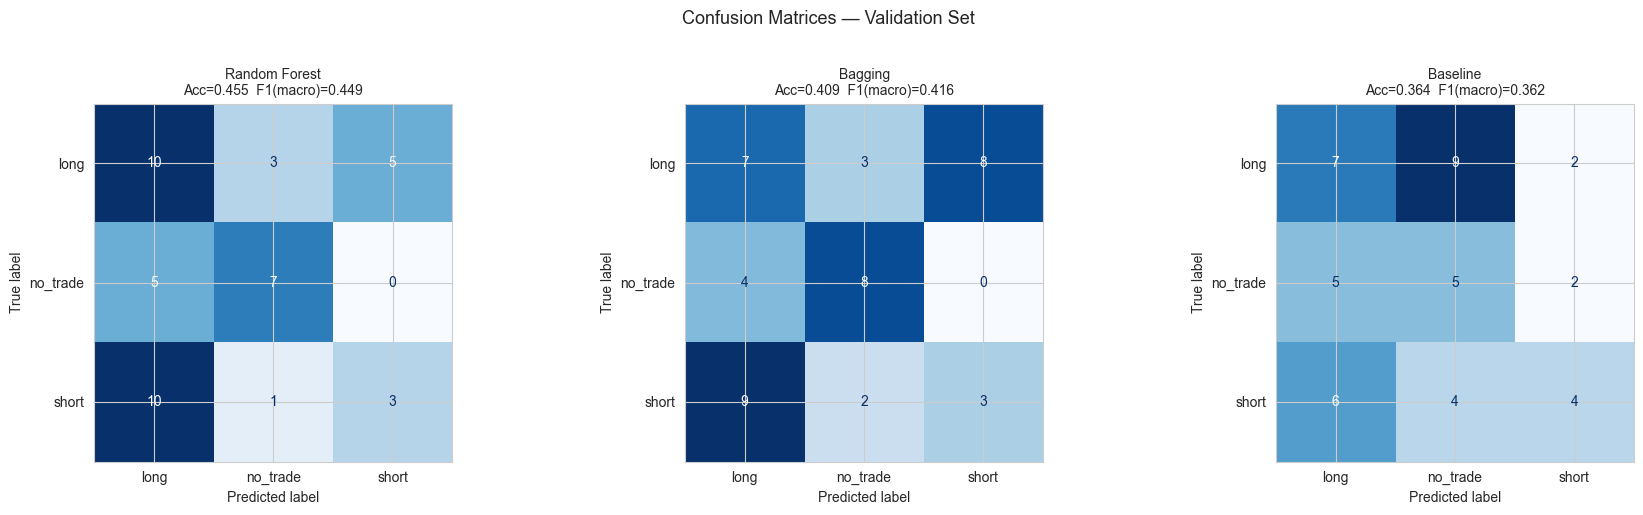

In [11]:
# Validation set confusion matrices (3 side-by-side)
val_results = results['val_results']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_keys = ['rf', 'bagging', 'baseline']
model_titles = ['Random Forest', 'Bagging', 'Baseline']

for i, (key, title) in enumerate(zip(model_keys, model_titles)):
    res = val_results[key]
    cm = res['confusion_matrix']
    disp = ConfusionMatrixDisplay(cm, display_labels=res['labels'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    acc = res['accuracy']
    f1 = res['f1_macro']
    axes[i].set_title(f'{title}\nAcc={acc:.3f}  F1(macro)={f1:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices — Validation Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Confusion Matrices — Test Set

The test set provides the final, unbiased evaluation. These numbers should be compared
to the validation results to check for overfitting.

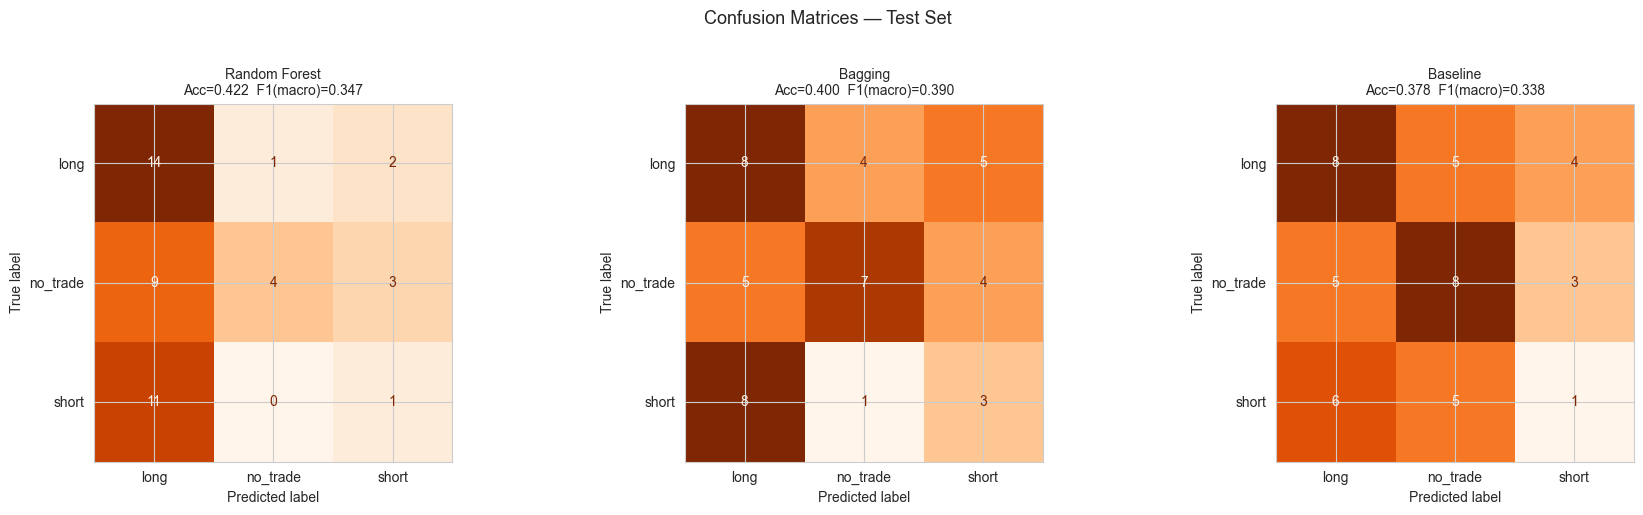

In [12]:
# Test set confusion matrices (3 side-by-side)
test_results = results['test_results']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (key, title) in enumerate(zip(model_keys, model_titles)):
    res = test_results[key]
    cm = res['confusion_matrix']
    disp = ConfusionMatrixDisplay(cm, display_labels=res['labels'])
    disp.plot(ax=axes[i], cmap='Oranges', colorbar=False)
    acc = res['accuracy']
    f1 = res['f1_macro']
    axes[i].set_title(f'{title}\nAcc={acc:.3f}  F1(macro)={f1:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Classification Reports

Per-class precision, recall, and F1-score for each model on both validation and test sets.

In [13]:
def report_to_df(report_dict, model_name):
    """Convert a classification_report dict to a tidy DataFrame."""
    rows = []
    for key in ['long', 'short', 'no_trade']:
        if key in report_dict:
            r = report_dict[key]
            rows.append({
                'Model': model_name,
                'Class': key,
                'Precision': round(r['precision'], 3),
                'Recall': round(r['recall'], 3),
                'F1-Score': round(r['f1-score'], 3),
                'Support': int(r['support']),
            })
    # Add macro avg
    if 'macro avg' in report_dict:
        r = report_dict['macro avg']
        rows.append({
            'Model': model_name,
            'Class': 'macro avg',
            'Precision': round(r['precision'], 3),
            'Recall': round(r['recall'], 3),
            'F1-Score': round(r['f1-score'], 3),
            'Support': int(r['support']),
        })
    return pd.DataFrame(rows)


# Validation reports
print('CLASSIFICATION REPORTS — VALIDATION SET')
print('=' * 65)
val_reports = []
for key, title in zip(model_keys, model_titles):
    rdf = report_to_df(val_results[key]['classification_report'], title)
    val_reports.append(rdf)
val_report_df = pd.concat(val_reports, ignore_index=True)
print(val_report_df.to_string(index=False))

print()
print('CLASSIFICATION REPORTS — TEST SET')
print('=' * 65)
test_reports = []
for key, title in zip(model_keys, model_titles):
    rdf = report_to_df(test_results[key]['classification_report'], title)
    test_reports.append(rdf)
test_report_df = pd.concat(test_reports, ignore_index=True)
print(test_report_df.to_string(index=False))

CLASSIFICATION REPORTS — VALIDATION SET
        Model     Class  Precision  Recall  F1-Score  Support
Random Forest      long      0.400   0.556     0.465       18
Random Forest     short      0.375   0.214     0.273       14
Random Forest  no_trade      0.636   0.583     0.609       12
Random Forest macro avg      0.470   0.451     0.449       44
      Bagging      long      0.350   0.389     0.368       18
      Bagging     short      0.273   0.214     0.240       14
      Bagging  no_trade      0.615   0.667     0.640       12
      Bagging macro avg      0.413   0.423     0.416       44
     Baseline      long      0.389   0.389     0.389       18
     Baseline     short      0.500   0.286     0.364       14
     Baseline  no_trade      0.278   0.417     0.333       12
     Baseline macro avg      0.389   0.364     0.362       44

CLASSIFICATION REPORTS — TEST SET
        Model     Class  Precision  Recall  F1-Score  Support
Random Forest      long      0.412   0.824     0.549     

---

## 11. Feature Importance

Feature importance from tree-based models measures how much each feature contributes to
reducing impurity (Gini) across all splits across all trees. Higher importance means the
feature is used more often and produces bigger impurity reductions.

In [14]:
# Feature importance tables
rf_fi = results['feature_importance']['rf']
bag_fi = results['feature_importance']['bagging']

print('Top 20 Feature Importances — Random Forest:')
print(rf_fi.to_string(index=False))
print()
print('Top 20 Feature Importances — Bagging:')
print(bag_fi.to_string(index=False))

Top 20 Feature Importances — Random Forest:
         feature  importance
      volume_std    0.047306
ma_spread_50_200    0.041740
     sma_10_dist    0.034513
           ret_5    0.033871
          mom_10    0.030528
           ret_1    0.029168
ma_spread_20_200    0.028691
    volume_ratio    0.028263
          rsi_14    0.026674
       macd_hist    0.026637
       event_atr    0.026581
          ret_10    0.026453
           mom_5    0.026427
         rvol_20    0.026178
     macd_signal    0.025405
     sma_50_dist    0.025289
          atr_14    0.025097
          mom_20    0.024655
        bb_width    0.024235
 ma_spread_10_50    0.023751

Top 20 Feature Importances — Bagging:
         feature  importance
      volume_std    0.094797
ma_spread_50_200    0.070459
           ret_1    0.048379
     sma_10_dist    0.048123
          rsi_14    0.043307
    volume_ratio    0.039107
       macd_hist    0.030908
ma_spread_20_200    0.028200
upper_mean_error    0.027574
         bb_pctb  

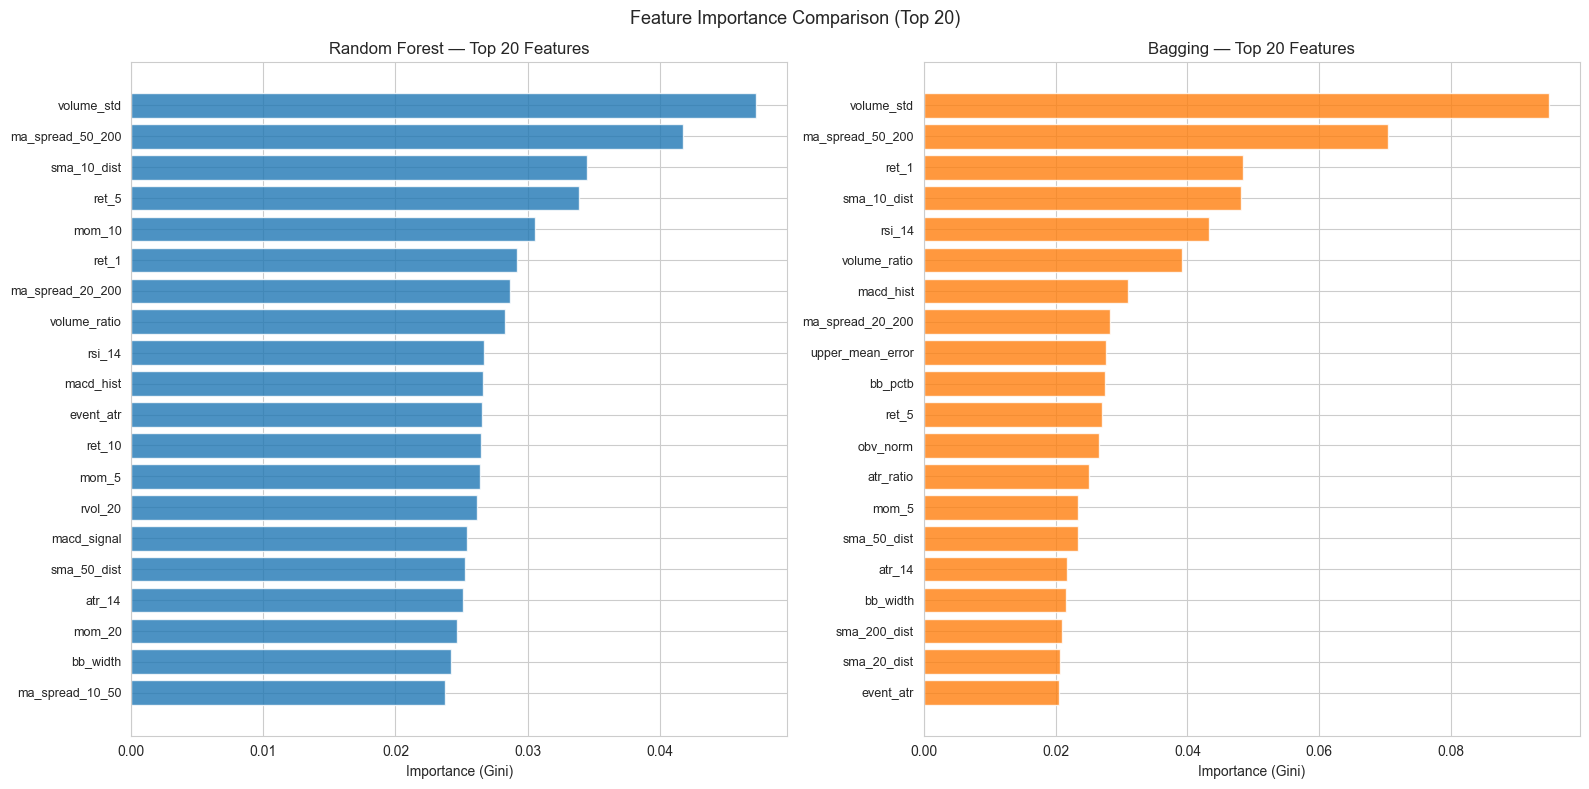

In [15]:
# Feature importance bar charts (top 20, side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest
rf_top = rf_fi.head(20)
axes[0].barh(range(len(rf_top)), rf_top['importance'].values,
             color='#1f77b4', alpha=0.8)
axes[0].set_yticks(range(len(rf_top)))
axes[0].set_yticklabels(rf_top['feature'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance (Gini)')
axes[0].set_title('Random Forest — Top 20 Features')

# Bagging
bag_top = bag_fi.head(20)
axes[1].barh(range(len(bag_top)), bag_top['importance'].values,
             color='#ff7f0e', alpha=0.8)
axes[1].set_yticks(range(len(bag_top)))
axes[1].set_yticklabels(bag_top['feature'].values, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance (Gini)')
axes[1].set_title('Bagging — Top 20 Features')

plt.suptitle('Feature Importance Comparison (Top 20)', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Importance overlap: which features appear in both top-20 lists?
rf_top20_set = set(rf_fi.head(20)['feature'])
bag_top20_set = set(bag_fi.head(20)['feature'])
overlap = rf_top20_set & bag_top20_set
rf_only = rf_top20_set - bag_top20_set
bag_only = bag_top20_set - rf_top20_set

print(f'Top-20 feature overlap: {len(overlap)} features in common')
print(f'  Shared:   {sorted(overlap)}')
print(f'  RF only:  {sorted(rf_only)}')
print(f'  Bag only: {sorted(bag_only)}')

Top-20 feature overlap: 14 features in common
  Shared:   ['atr_14', 'bb_width', 'event_atr', 'ma_spread_20_200', 'ma_spread_50_200', 'macd_hist', 'mom_5', 'ret_1', 'ret_5', 'rsi_14', 'sma_10_dist', 'sma_50_dist', 'volume_ratio', 'volume_std']
  RF only:  ['ma_spread_10_50', 'macd_signal', 'mom_10', 'mom_20', 'ret_10', 'rvol_20']
  Bag only: ['atr_ratio', 'bb_pctb', 'obv_norm', 'sma_200_dist', 'sma_20_dist', 'upper_mean_error']


---

## 12. Model Comparison Summary

Side-by-side comparison of all three models on both validation and test sets.

In [17]:
# Summary comparison table
summary_rows = []
for key, title in zip(model_keys, model_titles):
    v = val_results[key]
    t = test_results[key]
    summary_rows.append({
        'Model': title,
        'Val Accuracy': v['accuracy'],
        'Val F1 (macro)': v['f1_macro'],
        'Val F1 (weighted)': v['f1_weighted'],
        'Test Accuracy': t['accuracy'],
        'Test F1 (macro)': t['f1_macro'],
        'Test F1 (weighted)': t['f1_weighted'],
    })

summary_df = pd.DataFrame(summary_rows)
print('MODEL COMPARISON SUMMARY')
print('=' * 80)
print(summary_df.to_string(index=False))

MODEL COMPARISON SUMMARY
        Model  Val Accuracy  Val F1 (macro)  Val F1 (weighted)  Test Accuracy  Test F1 (macro)  Test F1 (weighted)
Random Forest        0.4545          0.4488             0.4431         0.4222           0.3470              0.3725
      Bagging        0.4091          0.4161             0.4016         0.4000           0.3904              0.4035
     Baseline        0.3636          0.3620             0.3657         0.3778           0.3383              0.3619


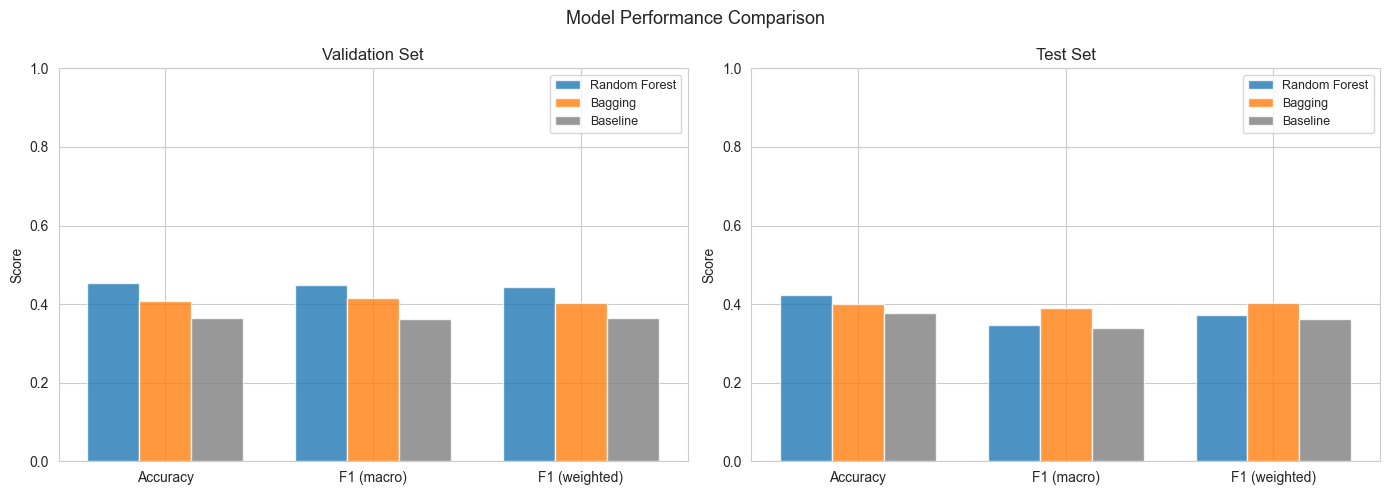

In [18]:
# Visual comparison: grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']
model_colors = {'Random Forest': '#1f77b4', 'Bagging': '#ff7f0e', 'Baseline': '#7f7f7f'}

# Validation
x = np.arange(len(metrics))
width = 0.25
for i, (key, title) in enumerate(zip(model_keys, model_titles)):
    v = val_results[key]
    vals = [v['accuracy'], v['f1_macro'], v['f1_weighted']]
    axes[0].bar(x + i * width, vals, width, label=title,
                color=model_colors[title], alpha=0.8)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Validation Set')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1)

# Test
for i, (key, title) in enumerate(zip(model_keys, model_titles)):
    t = test_results[key]
    vals = [t['accuracy'], t['f1_macro'], t['f1_weighted']]
    axes[1].bar(x + i * width, vals, width, label=title,
                color=model_colors[title], alpha=0.8)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].set_title('Test Set')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)

plt.suptitle('Model Performance Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---

## 13. Probability Calibration

Well-calibrated probabilities mean that when the model says "70% chance of long",
about 70% of those predictions should actually be long. We check calibration using
the predicted probabilities from RF and Bagging on the test set.

Note: with small test sets, calibration curves may be noisy.

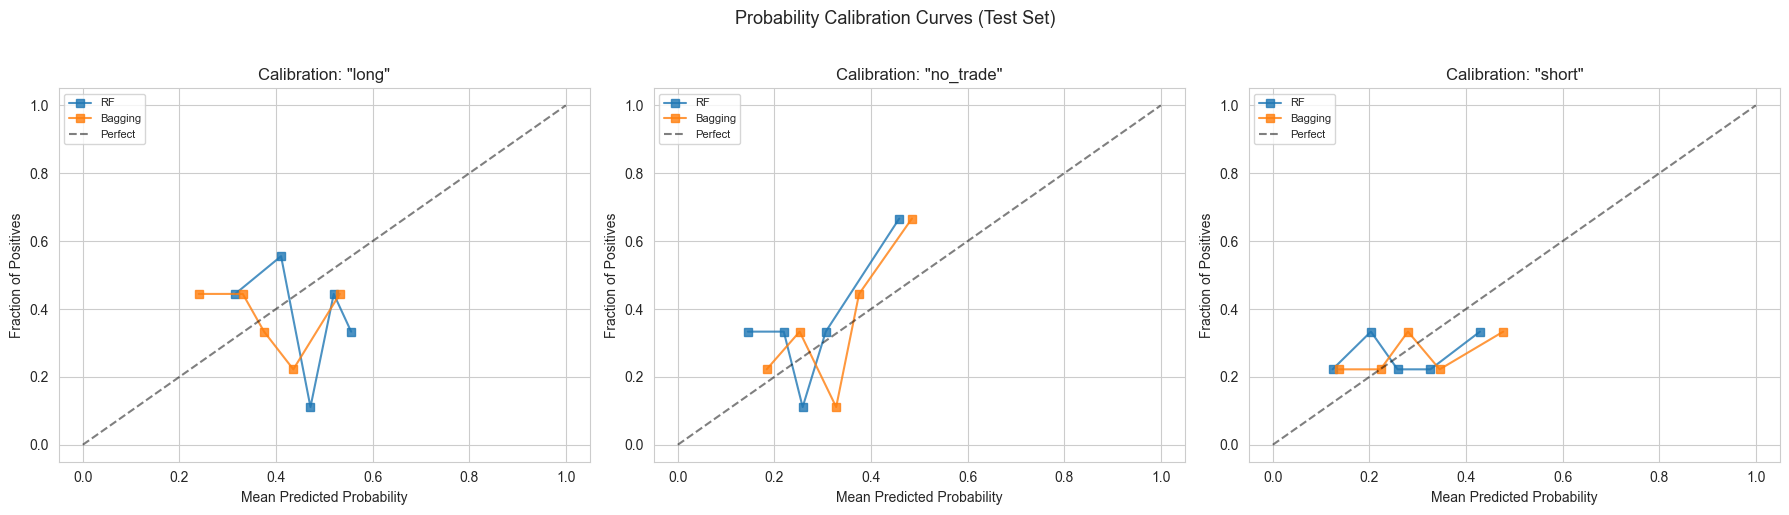

Note: With small test sets, calibration curves can be noisy.
A line close to the diagonal indicates good calibration.


In [19]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_test = split['y_test']
X_test = split['X_test']
class_labels = sorted(y_test.unique())

for col_idx, lbl in enumerate(class_labels):
    ax = axes[col_idx]
    y_binary = (y_test == lbl).astype(int)

    for model, name, color in [(rf_model, 'RF', '#1f77b4'),
                                (bag_model, 'Bagging', '#ff7f0e')]:
        proba = model.predict_proba(X_test)
        class_idx = list(model.classes_).index(lbl)
        proba_class = proba[:, class_idx]

        try:
            fraction_pos, mean_predicted = calibration_curve(
                y_binary, proba_class, n_bins=5, strategy='quantile'
            )
            ax.plot(mean_predicted, fraction_pos, 's-', color=color,
                    label=name, alpha=0.8)
        except ValueError:
            ax.text(0.5, 0.5, f'{name}: too few samples',
                    ha='center', va='center', transform=ax.transAxes)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Calibration: "{lbl}"')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Probability Calibration Curves (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Note: With small test sets, calibration curves can be noisy.')
print('A line close to the diagonal indicates good calibration.')

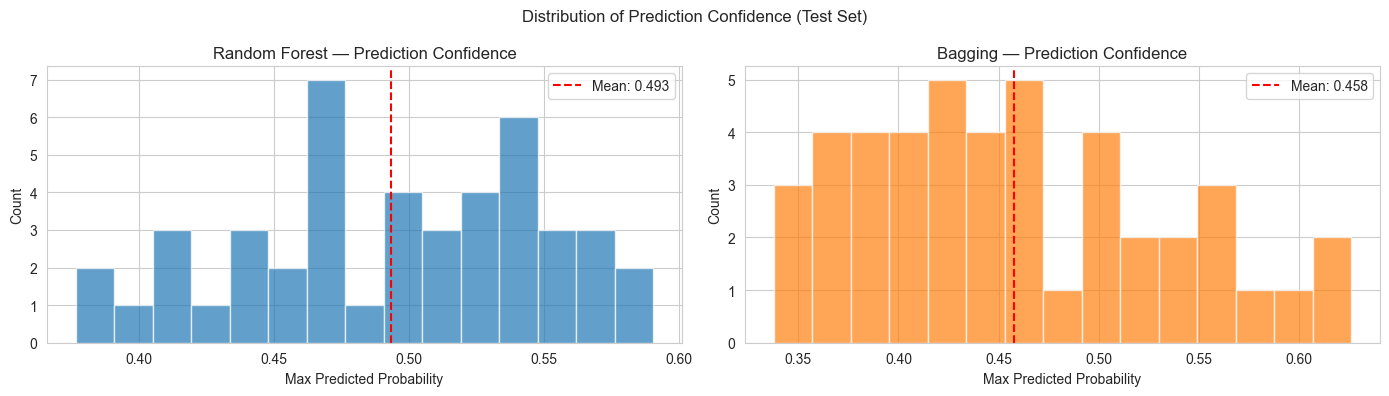

In [20]:
# Confidence distribution: histogram of max predicted probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, model, name, color in [(axes[0], rf_model, 'Random Forest', '#1f77b4'),
                                (axes[1], bag_model, 'Bagging', '#ff7f0e')]:
    proba = model.predict_proba(X_test)
    max_proba = proba.max(axis=1)
    ax.hist(max_proba, bins=15, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(max_proba.mean(), color='red', linestyle='--',
               label=f'Mean: {max_proba.mean():.3f}')
    ax.set_xlabel('Max Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Prediction Confidence')
    ax.legend()

plt.suptitle('Distribution of Prediction Confidence (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

---

## 14. Validation vs Test Performance Check

A large gap between validation and test performance would indicate overfitting
to the validation period. Ideally, test performance is close to validation performance.

In [21]:
# Overfitting check: val vs test
overfit_rows = []
for key, title in zip(model_keys, model_titles):
    v = val_results[key]
    t = test_results[key]
    overfit_rows.append({
        'Model': title,
        'Val Acc': v['accuracy'],
        'Test Acc': t['accuracy'],
        'Acc Gap': round(v['accuracy'] - t['accuracy'], 4),
        'Val F1': v['f1_macro'],
        'Test F1': t['f1_macro'],
        'F1 Gap': round(v['f1_macro'] - t['f1_macro'], 4),
    })

overfit_df = pd.DataFrame(overfit_rows)
print('Validation vs Test Gap (positive = val better, possible overfit):')
print(overfit_df.to_string(index=False))

Validation vs Test Gap (positive = val better, possible overfit):
        Model  Val Acc  Test Acc  Acc Gap  Val F1  Test F1  F1 Gap
Random Forest   0.4545    0.4222   0.0323  0.4488   0.3470  0.1018
      Bagging   0.4091    0.4000   0.0091  0.4161   0.3904  0.0257
     Baseline   0.3636    0.3778  -0.0142  0.3620   0.3383  0.0237


---

## 15. Key Findings & Discussion

### Model Performance

Refer to the summary table above for exact numbers. Key observations:

1. **Random Forest vs Bagging**: RF uses random feature subsets at each split, which
   decorrelates trees and typically improves generalization. Bagging uses all features,
   so its trees are more similar (higher inter-tree correlation). The performance gap
   between them reveals how much the random feature subset matters for this dataset.

2. **Both vs Baseline**: Both ensemble models should substantially outperform the
   stratified dummy. If they do not, it suggests the features lack predictive power
   for the label, or the dataset is too small.

3. **Overfitting**: Compare validation and test metrics. A small gap suggests the model
   generalizes; a large gap signals overfitting to the validation period.

### Feature Importance

The feature importance plots reveal which technical indicators and pattern geometry
features drive predictions. Overlap between RF and Bagging top features indicates
robust signal; features that rank high only in Bagging may reflect the dominant-feature
effect (where Bagging trees all split on the same feature).

### Limitations

- **Small dataset**: ~150 events split into 60/20/20 gives small validation and test
  sets. Metrics may have high variance.
- **No hyperparameter search**: We used fixed hyperparameters (200 trees, max_depth=8).
  A grid search or cross-validation could improve results but risks overfitting with
  small data.
- **Class imbalance**: Addressed via `class_weight="balanced"` in RF, but Bagging's
  DecisionTreeClassifier does not have this by default.
- **Temporal dependence**: Even with temporal splitting, nearby events may share similar
  market conditions, creating subtle leakage.

### Next Steps

- **Phase 8 (Backtest)**: Use model predictions to simulate trading and measure
  risk-adjusted returns.
- **Phase 4 (HMM Regimes)**: Add regime features (bull/bear/sideways) to the feature
  matrix and retrain.
- Consider adding more events (lower detection thresholds) to increase sample size.
- Explore calibration-aware thresholds for trade entry decisions.